# HDC embeddings — distances & clustering (German novels)

Explore the character-aware, self-referentially-learned binary word vectors from the `HDC`
package: nearest neighbours, a similarity matrix, the pairwise-similarity distribution
(collapse check), **k-majority clustering**, and a **classical-MDS map** — all rendered with
inline SVG, so the only requirements are the Julia `IJulia` kernel and the `HDC` package
(no plotting libraries).

> **Launch Jupyter from inside the `hdc/` folder** so the project resolves.
> First time: `julia`, then `] add IJulia`, then `using IJulia; notebook()`.

In [1]:
using Pkg
function _find_hdc(start=pwd())
    d = start
    while true
        f = joinpath(d, "Project.toml")
        (isfile(f) && occursin("name = \"HDC\"", read(f, String))) && return d
        p = dirname(d); p == d && break; d = p
    end
    error("Run this notebook from inside hdc/ (couldn't find HDC's Project.toml).")
end
const HDCDIR = _find_hdc()
Pkg.activate(HDCDIR); Pkg.instantiate()
using HDC, Random, LinearAlgebra, Statistics
println("HDC project: ", HDCDIR)

  Activating project at `d:\Moje dokumenty\Code\LambdaG\hdc`


HDC project: d:\Moje dokumenty\Code\LambdaG\hdc


## 1. Load real German prose (the LambdaG novels reference set)

In [2]:
NOVELS   = joinpath(HDCDIR, "..", "german", "av_reference_novels_de.jsonl")
MAXDOCS  = 80        # documents to read
MAXSENTS = 6000      # cap sentences (training cost scales with this)
MINCOUNT = 10        # drop words rarer than this
D        = 6144      # hypervector bits
FORMHOLD = D ÷ 2     # frozen character-form bits (structure that survives training)
EPOCHS   = 3

# --- minimal JSONL string-field reader (no JSON dependency) ---
function _jstr(s, i)
    io = IOBuffer(); i = nextind(s, i); n = lastindex(s)
    while i <= n
        c = s[i]
        if c == '\\'
            i = nextind(s, i); e = s[i]
            if     e == 'n'; write(io, '\n')
            elseif e == 't'; write(io, '\t')
            elseif e == 'r'; write(io, '\r')
            elseif e == 'u'; write(io, Char(parse(UInt16, s[nextind(s,i):nextind(s,i,4)]; base=16))); i = nextind(s,i,4)
            else write(io, e) end
            i = nextind(s, i)
        elseif c == '"'; return String(take!(io))
        else write(io, c); i = nextind(s, i) end
    end
    String(take!(io))
end
function _field(line, key)
    p = findfirst("\"" * key * "\"", line); p === nothing && return ""
    i = nextind(line, last(p)); while i <= lastindex(line) && line[i] != '"'; i = nextind(line, i); end
    i > lastindex(line) ? "" : _jstr(line, i)
end
_tok(t) = [w for ch in split(t, r"[.!?\n]+")
           for w in (String[m.match for m in eachmatch(r"[a-zäöüß]+", lowercase(ch))],)
           if length(w) >= 2]
function load_novels(path; maxdocs, maxsents)
    S = Vector{String}[]
    open(path) do io
        for (d, line) in enumerate(eachline(io))
            d > maxdocs && break
            isempty(strip(line)) && continue
            append!(S, _tok(_field(line, "text")))
            maxsents > 0 && length(S) >= maxsents && break
        end
    end
    maxsents > 0 ? S[1:min(end, maxsents)] : S
end

sents = load_novels(NOVELS; maxdocs = MAXDOCS, maxsents = MAXSENTS)
vocab, w2i, counts, ids = build_vocab(sents; min_count = MINCOUNT)
println(length(sents), " sentences, ", sum(length, ids; init=0), " tokens, vocab ", length(vocab))

6000 sentences, 86056 tokens, vocab 1221


## 2. Character-aware embeddings (form-anchored)

Each word atom is initialised from its character trigrams; the low `FORMHOLD` bits are frozen
so the spelling structure survives context learning.

In [3]:
cb = Codebook(D, vocab, w2i, counts; sub = 3, formhold = FORMHOLD, rng = MersenneTwister(1))
ce = CharEncoder(vocab, D; sub = 3, pos = POS_NONE, rng = MersenneTwister(2))
init_from_forms!(cb, ce; rng = MersenneTwister(3))
println("char-form init done — $FORMHOLD/$D bits frozen, $(D-FORMHOLD) learnable")

probes = filter(w -> haskey(w2i, w),
    ["mann","frau","kind","haus","auge","hand","liebe","leben","gehen","sagen","gut","gross"])
println("\n[character structure only] nearest neighbours:")
for w in probes[1:min(6,end)]; println("  $w -> ", nearest(cb, w; k = 6)); end

char-form init done — 3072/6144 bits frozen, 3072 learnable

[character structure only] nearest neighbours:
  mann -> [("man", 0.558), ("manne", 0.53), ("kann", 0.47), ("wann", 0.466), ("dann", 0.461), ("genannt", 0.458)]
  frau -> [("frage", 0.382), ("kraft", 0.362), ("traurig", 0.326), ("darum", 0.322), ("darauf", 0.319), ("fragte", 0.317)]
  kind -> [("kinde", 0.468), ("kindern", 0.447), ("kinn", 0.394), ("kinder", 0.384), ("sind", 0.374), ("wind", 0.365)]
  haus -> [("aus", 0.505), ("hause", 0.487), ("haupt", 0.393), ("durchaus", 0.388), ("heraus", 0.38), ("hinaus", 0.348)]
  auge -> [("augen", 0.491), ("aus", 0.348), ("auf", 0.34), ("zunge", 0.335), ("wiege", 0.318), ("junge", 0.318)]
  hand -> [("hanni", 0.395), ("stand", 0.388), ("hanne", 0.384), ("wand", 0.376), ("fand", 0.371), ("land", 0.367)]


## 3. Train (adds context on the learnable bits)

In [4]:
enc = Encoder(cb; stride = 1, pos = POS_GRADED, maxwin = 20, rng = MersenneTwister(4))
train!(enc, ids, AttractRepel(3, 7, 3); window = 5, epochs = EPOCHS, rng = MersenneTwister(5), log = stdout)
println("\n[form + learned context] nearest neighbours:")
for w in probes[1:min(8,end)]; println("  $w -> ", nearest(cb, w; k = 6)); end

  epoch 1  (mean_sim = 0.101, sim_std = 0.043, bit_entropy = 0.92, purity = NaN)
  epoch 2  (mean_sim = 0.102, sim_std = 0.043, bit_entropy = 0.92, purity = NaN)
  epoch 3  (mean_sim = 0.102, sim_std = 0.043, bit_entropy = 0.92, purity = NaN)

[form + learned context] nearest neighbours:
  mann -> [("man", 0.291), ("manne", 0.262), ("dann", 0.246), ("genannt", 0.245), ("kann", 0.244), ("mannes", 0.242)]
  frau -> [("frage", 0.198), ("kraft", 0.19), ("traurig", 0.162), ("fragte", 0.16), ("darauf", 0.159), ("graf", 0.159)]
  kind -> [("kindern", 0.243), ("kinde", 0.242), ("kinn", 0.201), ("sind", 0.201), ("links", 0.193), ("wind", 0.188)]
  haus -> [("aus", 0.278), ("hause", 0.253), ("durchaus", 0.227), ("haupt", 0.215), ("heraus", 0.199), ("hat", 0.192)]
  auge -> [("augen", 0.283), ("auf", 0.22), ("aus", 0.208), ("gegen", 0.192), ("zunge", 0.19), ("tage", 0.189)]
  hand -> [("stand", 0.237), ("fand", 0.221), ("wand", 0.219), ("land", 0.207), ("bestand", 0.202), ("niemand", 0.199)]
  li

## Helpers — clustering, MDS, and inline SVG (no external packages)

In [5]:
struct SVGImg; s::String; end
Base.show(io::IO, ::MIME"image/svg+xml", x::SVGImg) = print(io, x.s)
_clamp8(v) = clamp(round(Int, v), 0, 255)

# HDC k-majority clustering: assign to nearest prototype, prototype = majority bundle of members
function kmajority(cb, idxs, k; iters = 40, rng = Random.default_rng())
    sp = cb.sp; acc = Vector{Int32}(undef, sp.W * 64)
    protos = [copy(@view cb.E[:, rand(rng, idxs)]) for _ in 1:k]
    labels = zeros(Int, length(idxs)); members = [Int[] for _ in 1:k]
    for _ in 1:iters
        changed = false; foreach(empty!, members)
        for (j, w) in enumerate(idxs)
            wv = @view cb.E[:, w]; best = 1; bd = hamming(wv, protos[1])
            for c in 2:k; d = hamming(wv, protos[c]); d < bd && (bd = d; best = c); end
            labels[j] != best && (changed = true); labels[j] = best; push!(members[best], w)
        end
        for c in 1:k
            isempty(members[c]) || bundle!(sp, protos[c], [@view cb.E[:, w] for w in members[c]], acc, rng)
        end
        changed || break
    end
    labels
end

# classical (metric) MDS of the Hamming-distance matrix -> 2-D coordinates
function mds2(cb, idxs)
    n = length(idxs); Dm = zeros(n, n)
    for i in 1:n, j in i+1:n
        d = hamming(@view(cb.E[:, idxs[i]]), @view(cb.E[:, idxs[j]])) / cb.sp.D
        Dm[i, j] = Dm[j, i] = d
    end
    J = I - fill(1/n, n, n); B = Symmetric(-0.5 * J * (Dm .^ 2) * J)
    F = eigen(B); ord = sortperm(F.values; rev = true)
    F.vectors[:, ord[1:2]] .* sqrt.(max.(F.values[ord[1:2]]', 0.0))
end

function svg_scatter(xy, txt, cl; w = 820, h = 560, pad = 30)
    n = size(xy, 1); xs = xy[:, 1]; ys = xy[:, 2]
    xmn, xmx = extrema(xs); ymn, ymx = extrema(ys)
    sx(x) = pad + (x - xmn)/(xmx - xmn + 1e-9)*(w - 2pad)
    sy(y) = h - (pad + (y - ymn)/(ymx - ymn + 1e-9)*(h - 2pad))
    pal = ["#e41a1c","#377eb8","#4daf4a","#984ea3","#ff7f00","#a65628","#f781bf","#17becf","#bcbd22","#7f7f7f"]
    io = IOBuffer(); print(io, "<svg xmlns='http://www.w3.org/2000/svg' width='$w' height='$h' font-family='sans-serif'>")
    for i in 1:n
        col = pal[(cl[i]-1) % length(pal) + 1]
        cx = round(sx(xs[i]); digits=1); cy = round(sy(ys[i]); digits=1)
        print(io, "<circle cx='$cx' cy='$cy' r='4' fill='$col' fill-opacity='0.85'/>")
        print(io, "<text x='$(cx+5)' y='$(cy-4)' font-size='9' fill='#333'>$(txt[i])</text>")
    end
    print(io, "</svg>"); SVGImg(String(take!(io)))
end

function svg_heatmap(M, labels; cell = 32, pad = 96)
    n = size(M, 1); w = pad + n*cell + 8; h = pad + n*cell + 8
    col(v) = v >= 0 ? "rgb($(_clamp8(255-155v)),$(_clamp8(255-205v)),$(_clamp8(255-205v)))" :
                      "rgb($(_clamp8(255+205v)),$(_clamp8(255+205v)),$(_clamp8(255+155v)))"
    io = IOBuffer(); print(io, "<svg xmlns='http://www.w3.org/2000/svg' width='$w' height='$h' font-family='sans-serif'>")
    for i in 1:n, j in 1:n
        x = pad + (j-1)*cell; y = pad + (i-1)*cell
        print(io, "<rect x='$x' y='$y' width='$cell' height='$cell' fill='$(col(M[i,j]))' stroke='#fff'/>")
    end
    for i in 1:n
        yc = pad + (i-1)*cell + cell/2
        print(io, "<text x='$(pad-4)' y='$(yc+3)' font-size='10' text-anchor='end'>$(labels[i])</text>")
        xc = pad + (i-1)*cell + cell/2
        print(io, "<text x='$xc' y='$(pad-4)' font-size='10' transform='rotate(-45 $xc $(pad-4))'>$(labels[i])</text>")
    end
    print(io, "</svg>"); SVGImg(String(take!(io)))
end

function svg_hist(xs; bins = 40, w = 640, h = 260, pad = 34, title = "")
    lo, hi = extrema(xs); cnt = zeros(Int, bins)
    for x in xs; k = clamp(floor(Int, (x-lo)/(hi-lo+1e-12)*bins) + 1, 1, bins); cnt[k] += 1; end
    mx = maximum(cnt); bw = (w - 2pad)/bins
    io = IOBuffer(); print(io, "<svg xmlns='http://www.w3.org/2000/svg' width='$w' height='$h' font-family='sans-serif'>")
    for k in 1:bins
        bh = (h - 2pad)*cnt[k]/mx; x = pad + (k-1)*bw; y = h - pad - bh
        print(io, "<rect x='$(round(x;digits=1))' y='$(round(y;digits=1))' width='$(round(bw-1;digits=1))' height='$(round(bh;digits=1))' fill='#377eb8'/>")
    end
    print(io, "<line x1='$pad' y1='$(h-pad)' x2='$(w-pad)' y2='$(h-pad)' stroke='#333'/>")
    print(io, "<text x='$pad' y='$(h-6)' font-size='11'>$(round(lo;digits=2))</text>")
    print(io, "<text x='$(w-pad-34)' y='$(h-6)' font-size='11'>$(round(hi;digits=2))</text>")
    isempty(title) || print(io, "<text x='$pad' y='16' font-size='12'>$title</text>")
    print(io, "</svg>"); SVGImg(String(take!(io)))
end
println("helpers loaded")

helpers loaded


## 4. Distances — similarity matrix for the probe words

Red = similar, blue = dissimilar (calibrated around 0). The diagonal is 1.

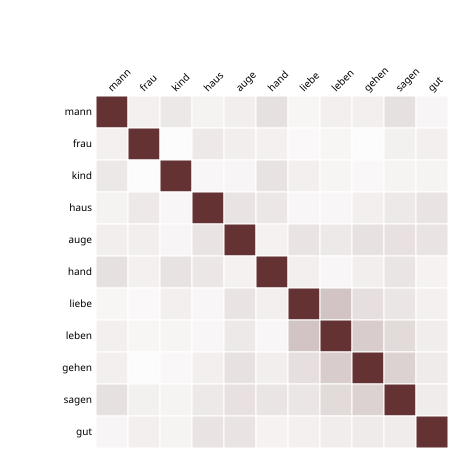

In [6]:
P = probes
M = [sim(cb.sp, @view(cb.E[:, w2i[a]]), @view(cb.E[:, w2i[b]])) for a in P, b in P]
svg_heatmap(M, P)

## 5. Distance distribution (collapse check)

If the space collapsed, this piles up near 1 with no spread; a healthy space is centred near 0
with a tail.

pairwise similarity: mean = 0.103  std = 0.048


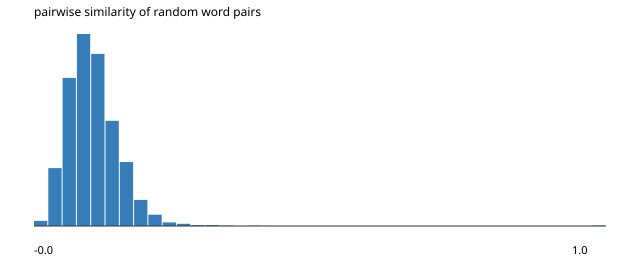

In [7]:
rng = MersenneTwister(0); V = length(vocab)
sims = [sim(cb.sp, @view(cb.E[:, rand(rng,1:V)]), @view(cb.E[:, rand(rng,1:V)])) for _ in 1:6000]
println("pairwise similarity: mean = ", round(mean(sims); digits=3), "  std = ", round(std(sims); digits=3))
svg_hist(sims; title = "pairwise similarity of random word pairs")

## 6. Clustering the learnt vectors (k-majority)

Cluster the most frequent words by Hamming distance (prototype = majority bundle).

In [8]:
# cluster CONTENT words: skip the ~30 most frequent (function words), take the next band
ord = sortperm(counts; rev = true)
top = ord[min(31, length(ord)):min(230, length(ord))]
K   = 8
lab = kmajority(cb, top, K; rng = MersenneTwister(9))
for c in 1:K
    ws = [vocab[top[j]] for j in eachindex(top) if lab[j] == c]
    isempty(ws) && continue
    println("cluster $c  (", length(ws), "):  ", join(first(ws, 16), ", "))
end

cluster 1  (33):  ihm, ihn, über, ihre, seine, oder, diese, herr, herta, seinem, ihrer, ihren, ohne, meine, ihrem, soll
cluster 2  (8):  um, im, s, immer, zum, arm, vom, zimmer
cluster 3  (44):  sein, mir, nur, vor, für, wieder, bei, dir, mein, wir, einer, wird, dieser, bis, unter, seiner
cluster 4  (59):  da, hatte, was, hat, jetzt, sagte, ja, haben, am, magnus, hand, man, nun, frau, ganz, selbst
cluster 5  (12):  wenn, denn, dann, mann, kann, hanne, konnte, lene, stand, können, gott, wendin
cluster 6  (9):  mich, dich, einem, nichts, heinrich, kein, dein, deine, gleich
cluster 7  (26):  nach, einen, mädchen, schon, leopold, mehr, seinen, werden, recht, gegen, ihnen, alten, haideröschen, machen, diesen, lassen
cluster 8  (9):  noch, aus, auch, doch, durch, alle, augen, euch, zurück


## 7. 2-D map (classical MDS of Hamming distance), coloured by cluster

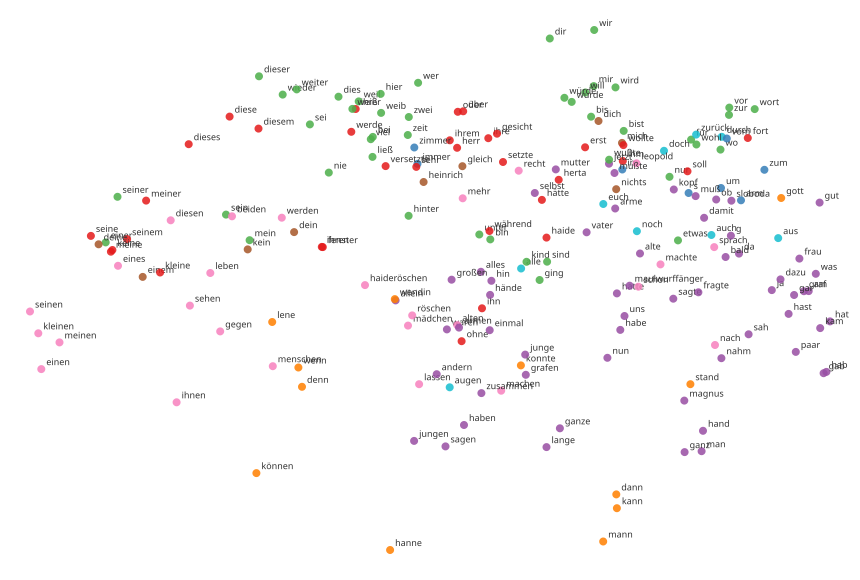

In [9]:
xy = mds2(cb, top)
svg_scatter(xy, [vocab[i] for i in top], lab; w = 860, h = 580)

## Notes

- Everything is **binary** — distances are Hamming, similarity `= 1 − 2·Hamming/D`.
- **`FORMHOLD`** trades retained spelling structure vs learnable context; the frozen half keeps
  morphological neighbours together even after training.
- Clustering/MDS run on the **learnt vectors**; raise `MAXSENTS`/`EPOCHS` (and lower `MINCOUNT`)
  for a richer space, at more compute. `kmajority` is random-initialised — reseed for stability.
- To compare rules, swap `AttractRepel(3,7,3)` for `Surprise(4)`, `EnergyAlign(6,5)`, or
  `SparseCapacity(3)` and re-run §4–7; watch the similarity distribution and `diagnostics(cb)`.